# Deserialization

Deserialization is the act of taking data (that can be provided in a number of ways) to create and populate a new model instance.

We already saw one way of doing this:

In [1]:
from pydantic import BaseModel, ValidationError

In [2]:
class Person(BaseModel):
    first_name: str
    last_name: str
    age: int

In [3]:
p = Person(first_name='Isaac', last_name='Newton', age=84)

It may not look like deserialization, but in essence that's what happened - we went from data provided as named argument, to an initialized instance.

We also saw that Pydantic will perform some validation as it does so.

Pydantic can handle deserializing data in two other formats:
- a Python `dict`
- a JSON string

Let's look at `dict` first:

In [4]:
data = {
    "first_name": "Isaac",
    "last_name": "Newton",
    "age": 84
}

To deserialize a dictionary we could technically use unpacking this way:

In [ ]:
Person(**data)

But this is not recommended. It works for simple models, but once you start getting into more complex models that use composition, you might run into issues.

Instead, Pydantic provides a specialized method to load data from a `dict` - the `model_validate()` method.

And, in fact, the method name clearly indicates that Pydantic is not just loading up data, but is also performing validation.

In [ ]:
p = Person.model_validate(data)
p

The same validation exceptions we saw earlier will be raised when we have validation issues:

In [ ]:
missing_data = {"last_name": "Newton"}

try:
    Person.model_validate(missing_data)
except ValidationError as ex:
    print(ex)

The second data format that Pydantic can deserialize is JSON. This is of course hugely beneficial when working with REST APIs, where requests and responses are typically in JSON format.

For that, Pydantic provides the `model_validate_json()` method.

In [ ]:
data_json = '''
{
    "first_name": "Isaac",
    "last_name": "Newton",
    "age": 84
}
'''

In [ ]:
p = Person.model_validate_json(data_json)
p

And validation exceptions happen just like before:

In [ ]:
missing_data_json = '''
{
    "last_name": "Newton"
}
'''

try:
    Person.model_validate_json(missing_data_json)
except ValidationError as ex:
    print(ex)

“Pydantic V1 vs. V2:  that dict() and parse_raw() have been deprecated in version 2. They should now use model_dump() and model_validate_json() as the standard replacements.”

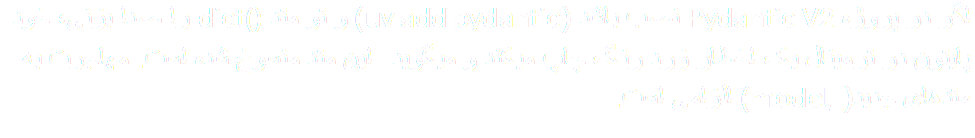